# Nama Dataset: Breast Cancer Wisconsin (Diagnostic) Dataset  
**Sumber**: [Kaggle - Breast Cancer Wisconsin Data](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

## Penjelasan Dataset  
Dataset ini merupakan data diagnostik kanker payudara yang diambil dari gambar digital inti sel tumor hasil biopsi.  
Tujuan utamanya adalah untuk memprediksi apakah tumor bersifat **ganas (malignant)** atau **jinak (benign)** berdasarkan fitur numerik.

## Struktur Dataset  
Dataset ini berbentuk file CSV dan berisi data numerik hasil ekstraksi citra.

## Fitur Dataset  
1. `id` → ID pasien (tidak digunakan dalam analisis)  
2. `diagnosis` → Diagnosis tumor (M = malignant, B = benign)  
3. `radius_mean` → Rata-rata jarak dari pusat ke batas sel  
4. `texture_mean` → Variasi tingkat abu-abu  
5. `perimeter_mean` → Keliling rata-rata sel  
6. `area_mean` → Luas rata-rata sel  
7. `smoothness_mean` → Variasi lokal panjang radius  
8. `compactness_mean` → Ukuran kompak sel  
9. `concavity_mean` → Tingkat cekungan kontur  
10. `concave points_mean` → Jumlah titik cekung pada kontur  
11. `symmetry_mean` → Tingkat simetri sel  
12. `fractal_dimension_mean` → Kompleksitas batas sel  
13. `*_se` → Kesalahan standar dari masing-masing fitur  
14. `*_worst` → Nilai maksimum dari fitur terkait (kondisi ekstrem)

## Jumlah Kelas  
- `M` → Malignant (ganas)  
- `B` → Benign (jinak)

**EDA (Exploratory Data Analysis)**

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Unduh dataset menggunakan KaggleHub
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
df = pd.read_csv(path + "/data.csv")

In [68]:
# Menampilkan beberapa baris pertama dari dataset
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [69]:
# Mengecek informasi dasar tentang dataset (tipe data, jumlah non-null)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [71]:
# Mengecek apakah ada nilai yang hilang di setiap kolom
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

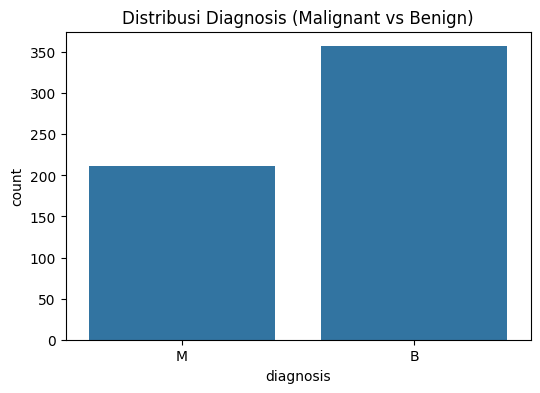

In [73]:
# Visualisasi distribusi variabel target (Malignant vs Benign)
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribusi Diagnosis (Malignant vs Benign)')
plt.show()

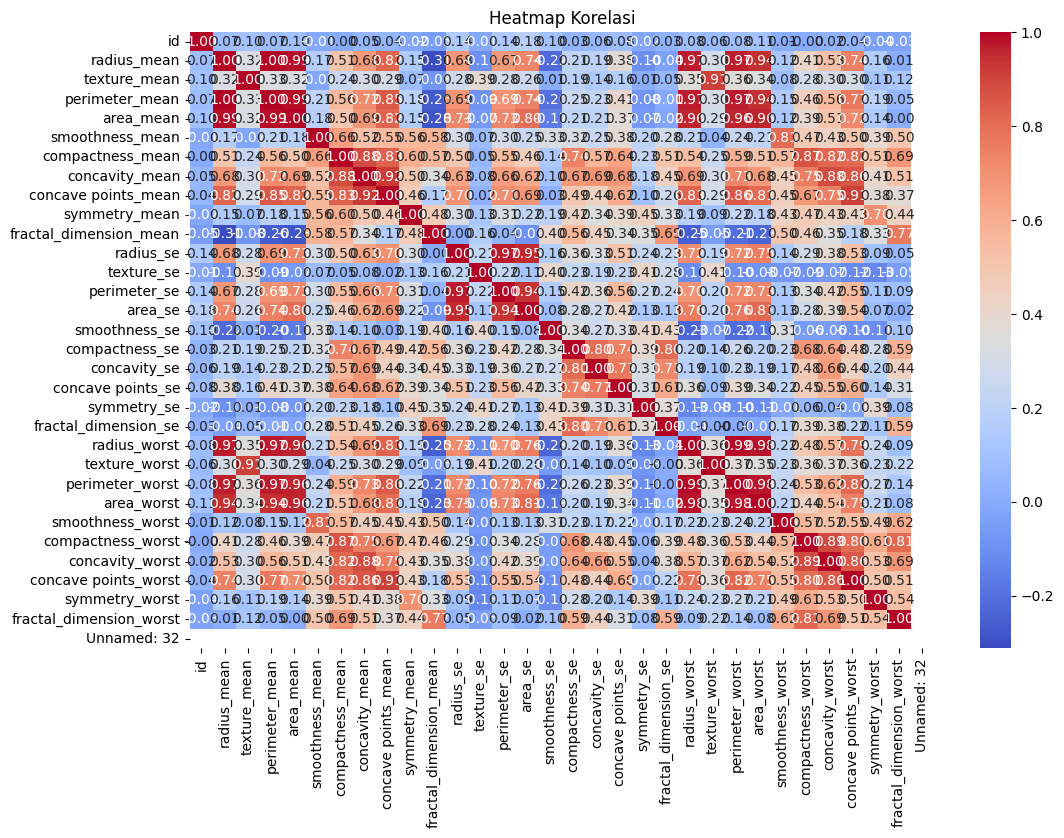

In [74]:
# Melihat korelasi antara fitur numerik
plt.figure(figsize=(12,8))
sns.heatmap(df.drop('diagnosis', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi')
plt.show()

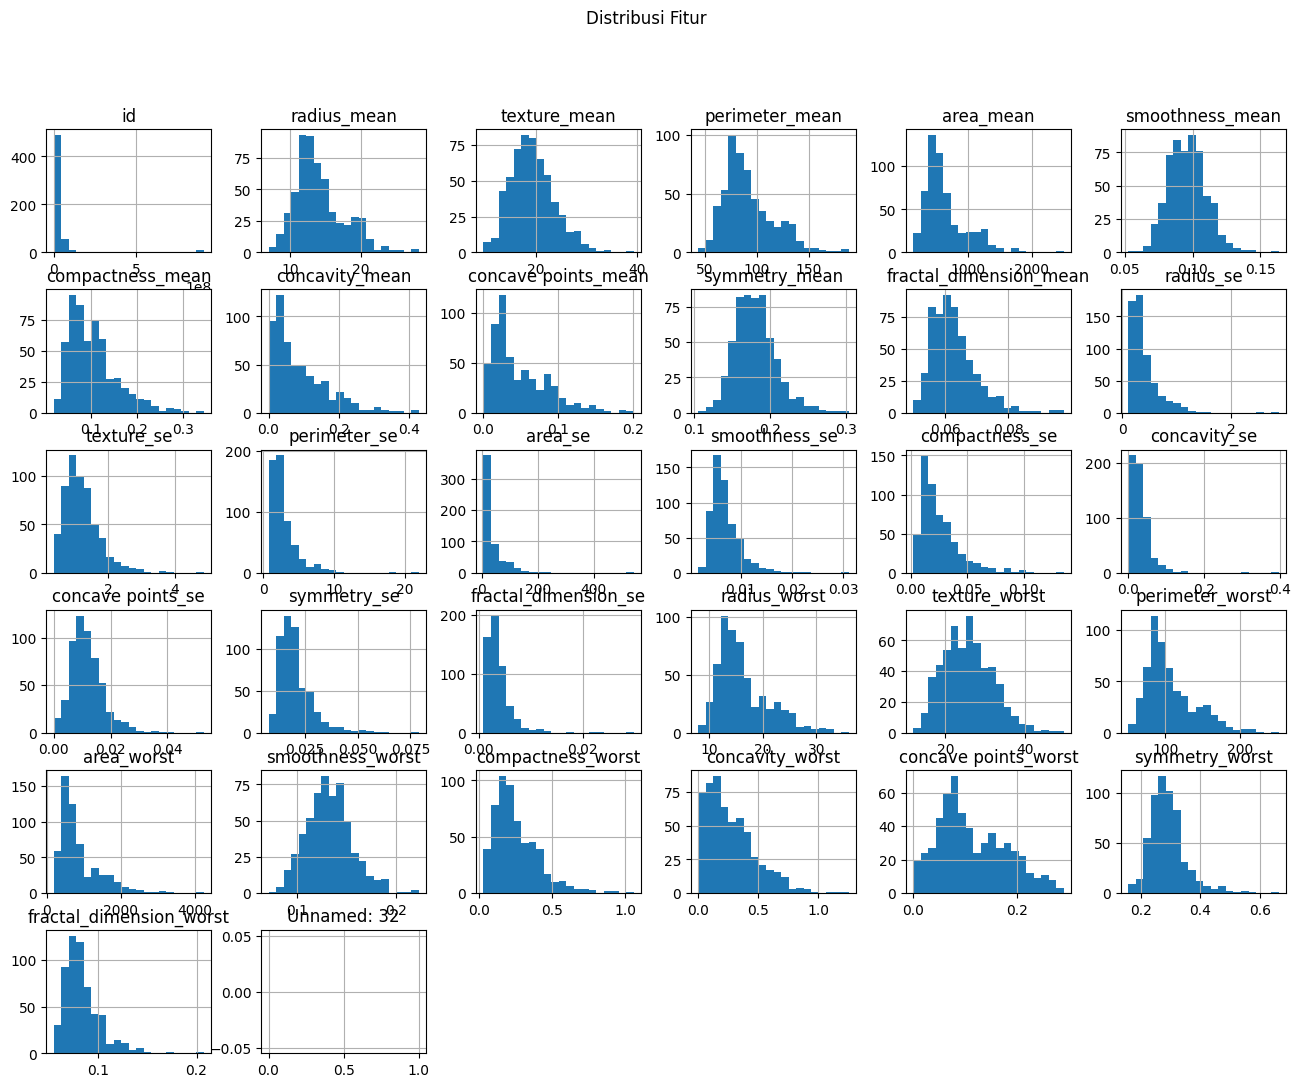

In [75]:
# Menampilkan distribusi dari fitur numerik
df.drop('diagnosis', axis=1).hist(bins=20, figsize=(16, 12))
plt.suptitle('Distribusi Fitur')
plt.show()

**Preprocessing (Pemrosesan Data)**

In [76]:
# Menghapus kolom yang tidak berguna seperti 'id' dan 'Unnamed: 32'
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)

In [77]:
# Mengubah label diagnosis dari 'M' dan 'B' menjadi biner: 1 = Malignant, 0 = Benign
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [78]:
# Memisahkan fitur (X) dan variabel target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [79]:
# Normalisasi fitur menggunakan StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [80]:
from sklearn.model_selection import train_test_split

# Membagi dataset menjadi data latih dan data uji (80-20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Menampilkan bentuk data latih dan uji
print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")

Bentuk X_train: (455, 30)
Bentuk X_test: (114, 30)


**Membangun dan melatih model Neural Network menggunakan Keras**

In [81]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Membangun model neural network
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
# Mengompilasi model dengan binary cross-entropy loss dan optimizer Adam
model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

In [83]:
# Menyiapkan early stopping untuk menghindari overfitting
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [84]:
# Melatih model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=200, batch_size=16, callbacks=[early_stop], verbose=1)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6511 - loss: 0.6321 - val_accuracy: 0.9231 - val_loss: 0.4514
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9032 - loss: 0.4325 - val_accuracy: 0.9231 - val_loss: 0.2811
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9299 - loss: 0.2809 - val_accuracy: 0.9341 - val_loss: 0.1944
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9480 - loss: 0.1970 - val_accuracy: 0.9560 - val_loss: 0.1538
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9550 - loss: 0.1514 - val_accuracy: 0.9560 - val_loss: 0.1318
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9469 - loss: 0.1401 - val_accuracy: 0.9451 - val_loss: 0.1216
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9818 - loss: 0.1079 - val_accuracy: 0.9670 - val_loss: 0.1232
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9803 - loss: 0.1052 - val_accuracy: 0.9560 - 

In [85]:
# Mengevaluasi model pada data uji
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Akurasi Uji: {test_accuracy:.4f}")

Akurasi Uji: 0.9825


In [88]:
from sklearn.metrics import confusion_matrix, classification_report

# Membuat prediksi pada data uji
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Menampilkan matriks kebingunguan dan laporan klasifikasi
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[72  0]
 [ 2 40]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



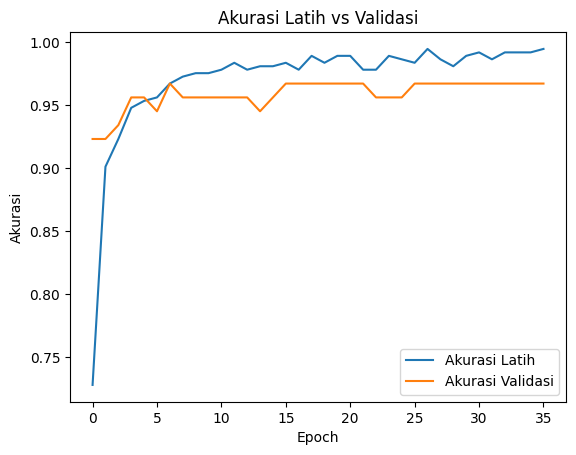

In [89]:
# Visualisasi akurasi latih vs validasi selama epoch
plt.plot(history.history['accuracy'], label='Akurasi Latih')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Akurasi Latih vs Validasi')
plt.show()

**Contoh Prediksi dengan model Neural Network**

In [98]:
import numpy as np

random_indices = np.random.choice(len(X_test), size=5, replace=False)

label_map = {0: "Benign", 1: "Malignant"}

print("Sample Predictions:\n")
for idx in random_indices:
    sample = X_test[idx].reshape(1, -1)
    prob = model.predict(sample)[0].item()
    prediction = int(prob > 0.5)
    true_label = int(y_test.iloc[idx])

    print(f"Sample Index: {y_test.index[idx]}")
    print(f"→ Predicted: {label_map[prediction]} (class {prediction}, prob={prob:.2f})")
    print(f"→ Actual:    {label_map[true_label]} (class {true_label})")
    print("-" * 40)

Sample Predictions:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Sample Index: 154
→ Predicted: Benign (class 0, prob=0.00)
→ Actual:    Benign (class 0)
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Sample Index: 169
→ Predicted: Benign (class 0, prob=0.01)
→ Actual:    Benign (class 0)
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Sample Index: 487
→ Predicted: Malignant (class 1, prob=1.00)
→ Actual:    Malignant (class 1)
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Sample Index: 296
→ Predicted: Benign (class 0, prob=0.00)
→ Actual:    Benign (class 0)
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Sample Index: 94
→ Predicted: Malignant (class 1, prob=1.00)
→ Actual:    Malignant (class 1)
----------------------------------------
